In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

cc_df = pd.read_csv('../data/raw/creditcard.csv')
print("Shape:", cc_df.shape)
print("\nMissing values:", cc_df.isnull().sum().sum())
print("\nDuplicates:", cc_df.duplicated().sum())
cc_df.head()

Shape: (284807, 31)

Missing values: 0

Duplicates: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


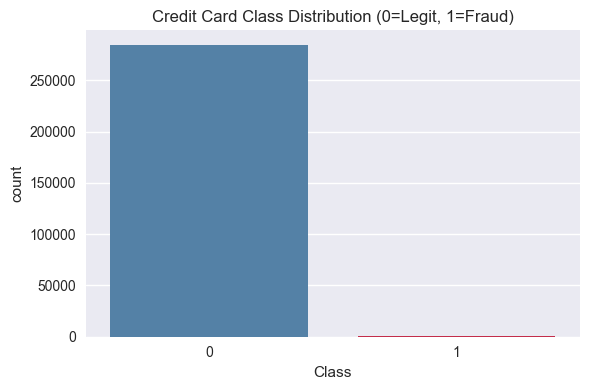

In [2]:
class_counts = cc_df['Class'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nFraud rate: {class_counts[1]/len(cc_df)*100:.4f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=cc_df, palette=['steelblue', 'crimson'])
plt.title('Credit Card Class Distribution (0=Legit, 1=Fraud)')
plt.tight_layout()
plt.savefig('../data/processed/cc_class_distribution.png')
plt.show()

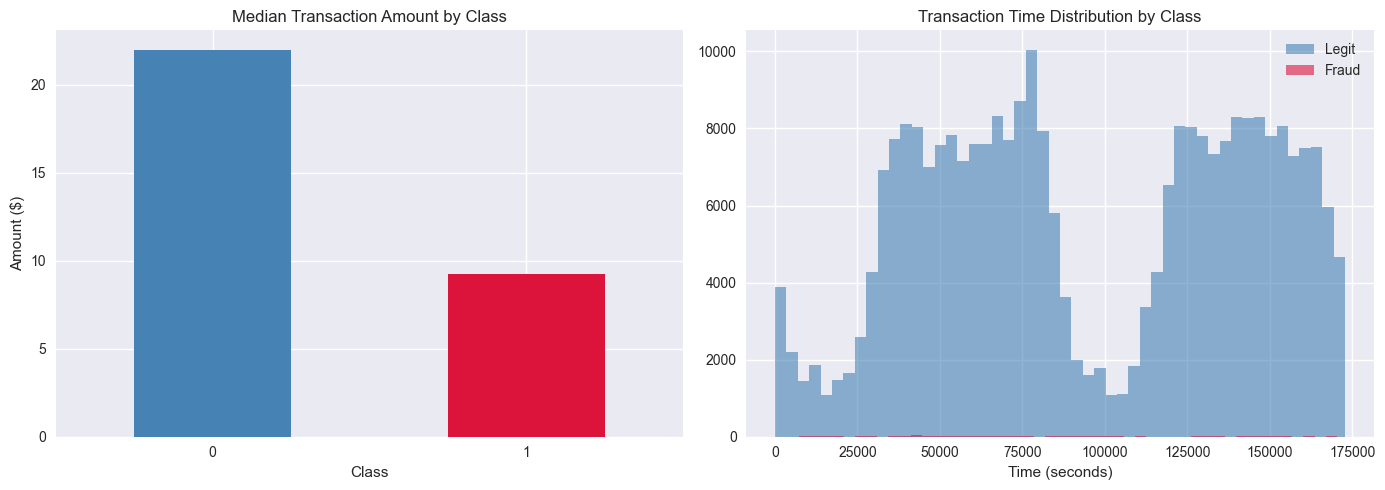

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount by class
cc_df.groupby('Class')['Amount'].median().plot(kind='bar', ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Median Transaction Amount by Class')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=0)

# Time distribution by class
axes[1].hist(cc_df[cc_df['Class']==0]['Time'], bins=50, alpha=0.6, color='steelblue', label='Legit')
axes[1].hist(cc_df[cc_df['Class']==1]['Time'], bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Transaction Time Distribution by Class')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/cc_eda.png')
plt.show()

In [4]:
# Scale Amount and Time (V1-V28 already PCA scaled)
scaler = StandardScaler()
cc_df['Amount_scaled'] = scaler.fit_transform(cc_df[['Amount']])
cc_df['Time_scaled'] = scaler.fit_transform(cc_df[['Time']])

# Drop originals
cc_df = cc_df.drop(columns=['Amount', 'Time'])

X = cc_df.drop(columns=['Class'])
y = cc_df['Class']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(y_train.value_counts())

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

# Save
pd.DataFrame(X_train_sm).to_csv('../data/processed/X_train_cc.csv', index=False)
pd.DataFrame(X_test).to_csv('../data/processed/X_test_cc.csv', index=False)
pd.Series(y_train_sm).to_csv('../data/processed/y_train_cc.csv', index=False)
pd.Series(y_test).to_csv('../data/processed/y_test_cc.csv', index=False)

print("\nCredit card data saved!")

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Credit card data saved!
